In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn as sns
import matplotlib.pyplot as plt


#For pretty display
pd.set_option('display.max_columns', None)



In [2]:
df = pd.read_csv(r"C:\My stuff\Coding\ML project\KiranveerSingh_Project\Dataset\food_nutrition_dataset.csv")
print(df.shape)
df.head()

(1000, 19)


,Food_Item,Category,Calories,Protein_g,Fat_g,Carbs_g,Fiber_g,Vitamin_A_mcg,Vitamin_C_mg,Vitamin_D_IU,Vitamin_B12_mcg,Iron_mg,Calcium_mg,Zinc_mg,Folate_mcg,Magnesium_mg,Tags,Allergens,Health_Benefits
0,Watermelon (87g),Fruit,34.5,7.2,6.8,44.5,8.2,713.9,7.8,168.8,0.07,2.3,156.6,0.2,83.5,99.2,Diabetic-Friendly,Nuts,Supports Bone Health
1,Beetroot (117g),Vegetable,181.4,21.8,22.8,10.4,5.2,223.0,19.4,305.4,0.25,3.9,114.1,1.8,109.5,11.3,Low-Fat,Soy,Boosts Immunity
2,Fish (Pomfret) (85g),Seafood,340.2,20.8,18.6,51.8,7.0,564.0,4.1,91.2,0.69,0.9,77.5,0.6,114.8,97.2,High-Protein,Dairy,Improves Digestion
3,Mutton (93g),Meat,408.7,17.7,20.5,5.2,7.7,427.8,22.0,184.9,0.65,9.3,209.6,1.2,133.1,116.4,Vegan,Dairy,Boosts Immunity
4,Egg (105g),Protein,175.3,5.7,28.3,52.7,3.9,524.7,35.6,365.8,1.10,2.7,81.5,2.9,108.8,89.8,Diabetic-Friendly,Nuts,Improves Digestion


In [3]:
#Check for Missing Values & Data Types
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Food_Item        1000 non-null   object 
 1   Category         1000 non-null   object 
 2   Calories         1000 non-null   float64
 3   Protein_g        1000 non-null   float64
 4   Fat_g            1000 non-null   float64
 5   Carbs_g          1000 non-null   float64
 6   Fiber_g          1000 non-null   float64
 7   Vitamin_A_mcg    1000 non-null   float64
 8   Vitamin_C_mg     1000 non-null   float64
 9   Vitamin_D_IU     1000 non-null   float64
 10  Vitamin_B12_mcg  1000 non-null   float64
 11  Iron_mg          1000 non-null   float64
 12  Calcium_mg       1000 non-null   float64
 13  Zinc_mg          1000 non-null   float64
 14  Folate_mcg       1000 non-null   float64
 15  Magnesium_mg     1000 non-null   float64
 16  Tags             1000 non-null   object 
 17  Allergens      

In [4]:
print(df.columns.tolist())


['Food_Item', 'Category', 'Calories', 'Protein_g', 'Fat_g', 'Carbs_g', 'Fiber_g', 'Vitamin_A_mcg', 'Vitamin_C_mg', 'Vitamin_D_IU', 'Vitamin_B12_mcg', 'Iron_mg', 'Calcium_mg', 'Zinc_mg', 'Folate_mcg', 'Magnesium_mg', 'Tags', 'Allergens', 'Health_Benefits']


In [5]:
#Clean the column names
df.columns = df.columns.str.strip().str.replace(" ", "_").str.replace(r"[^\w\s]", "", regex=True)
print(df.columns.tolist())  # Check again


['Food_Item', 'Category', 'Calories', 'Protein_g', 'Fat_g', 'Carbs_g', 'Fiber_g', 'Vitamin_A_mcg', 'Vitamin_C_mg', 'Vitamin_D_IU', 'Vitamin_B12_mcg', 'Iron_mg', 'Calcium_mg', 'Zinc_mg', 'Folate_mcg', 'Magnesium_mg', 'Tags', 'Allergens', 'Health_Benefits']


In [6]:
# Separate columns by datatype
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Fill numeric columns with mean
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

# Fill categorical columns with mode
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


In [7]:
# Show missing values after cleaning
print("\nMissing values after cleaning:\n", df.isnull().sum())

# Preview cleaned data
df.head()


Missing values after cleaning:
 Food_Item          0
Category           0
Calories           0
Protein_g          0
Fat_g              0
Carbs_g            0
Fiber_g            0
Vitamin_A_mcg      0
Vitamin_C_mg       0
Vitamin_D_IU       0
Vitamin_B12_mcg    0
Iron_mg            0
Calcium_mg         0
Zinc_mg            0
Folate_mcg         0
Magnesium_mg       0
Tags               0
Allergens          0
Health_Benefits    0
dtype: int64


,Food_Item,Category,Calories,Protein_g,Fat_g,Carbs_g,Fiber_g,Vitamin_A_mcg,Vitamin_C_mg,Vitamin_D_IU,Vitamin_B12_mcg,Iron_mg,Calcium_mg,Zinc_mg,Folate_mcg,Magnesium_mg,Tags,Allergens,Health_Benefits
0,Watermelon (87g),Fruit,34.5,7.2,6.8,44.5,8.2,713.9,7.8,168.8,0.07,2.3,156.6,0.2,83.5,99.2,Diabetic-Friendly,Nuts,Supports Bone Health
1,Beetroot (117g),Vegetable,181.4,21.8,22.8,10.4,5.2,223.0,19.4,305.4,0.25,3.9,114.1,1.8,109.5,11.3,Low-Fat,Soy,Boosts Immunity
2,Fish (Pomfret) (85g),Seafood,340.2,20.8,18.6,51.8,7.0,564.0,4.1,91.2,0.69,0.9,77.5,0.6,114.8,97.2,High-Protein,Dairy,Improves Digestion
3,Mutton (93g),Meat,408.7,17.7,20.5,5.2,7.7,427.8,22.0,184.9,0.65,9.3,209.6,1.2,133.1,116.4,Vegan,Dairy,Boosts Immunity
4,Egg (105g),Protein,175.3,5.7,28.3,52.7,3.9,524.7,35.6,365.8,1.10,2.7,81.5,2.9,108.8,89.8,Diabetic-Friendly,Nuts,Improves Digestion


In [8]:
#Standardize Column Names
df.columns = df.columns.str.strip().str.replace(" ", "_").str.replace(r"[^\w\s]", "")


In [9]:
#Remove Duplicates
df = df.drop_duplicates()


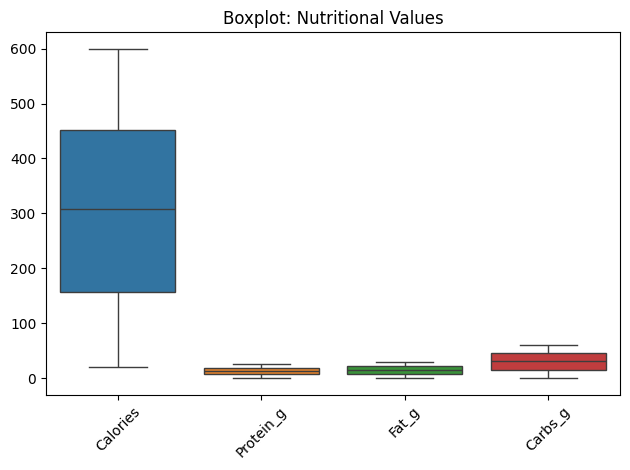

In [10]:
#Check for Outliers
sns.boxplot(data=df[['Calories', 'Protein_g', 'Fat_g', 'Carbs_g']])
plt.xticks(rotation=45)
plt.title("Boxplot: Nutritional Values")
plt.tight_layout()
plt.show()


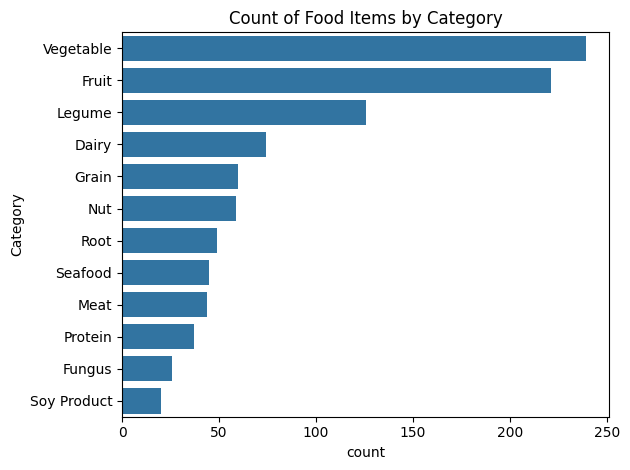

In [11]:
#Visual Exploration
sns.countplot(data=df, y='Category', order=df['Category'].value_counts().index)
plt.title("Count of Food Items by Category")
plt.tight_layout()
plt.show()


In [12]:
#Saving cleaned data to new csv file
df.to_csv("C:\My stuff\Coding\ML project\KiranveerSingh_Project\Dataset/cleaned_food_nutrition_dataset.csv", index=False)
print("Cleaned dataset saved to 'Dataset/cleaned_food_nutrition_dataset.csv'")


Cleaned dataset saved to 'Dataset/cleaned_food_nutrition_dataset.csv'


<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:2: SyntaxWarning: invalid escape sequence '\M'
C:\Users\mrran\AppData\Local\Temp\ipykernel_20448\3289890193.py:2: SyntaxWarning: invalid escape sequence '\M'
  df.to_csv("C:\My stuff\Coding\ML project\KiranveerSingh_Project\Dataset/cleaned_food_nutrition_dataset.csv", index=False)
